In [2]:
pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

In [4]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

In [20]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [21]:
from xgboost import XGBClassifier

In [22]:
df=pd.read_csv('credit_dataset_5000_enhanced_final.csv')

In [23]:
df.shape

(5000, 9)

In [24]:
df.isnull().sum()

Age                   0
Income                0
Coapplicant_Income    0
Dependents            0
Employ_Status         0
Debt                  0
PrevLDefault          0
CIBIL_Score           0
Loan_Approval         0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.head()

,Age,Income,Coapplicant_Income,Dependents,Employ_Status,Debt,PrevLDefault,CIBIL_Score,Loan_Approval
0,61,26587,10296,1,Employed,56824,1,465,0
1,36,23236,13264,3,Self-employed,78620,1,456,1
2,66,19245,32648,5,Employed,34596,0,572,0
3,29,64148,19563,1,Employed,59612,0,620,0
4,43,101424,49221,1,Unemployed,1523,0,659,0


<Axes: >

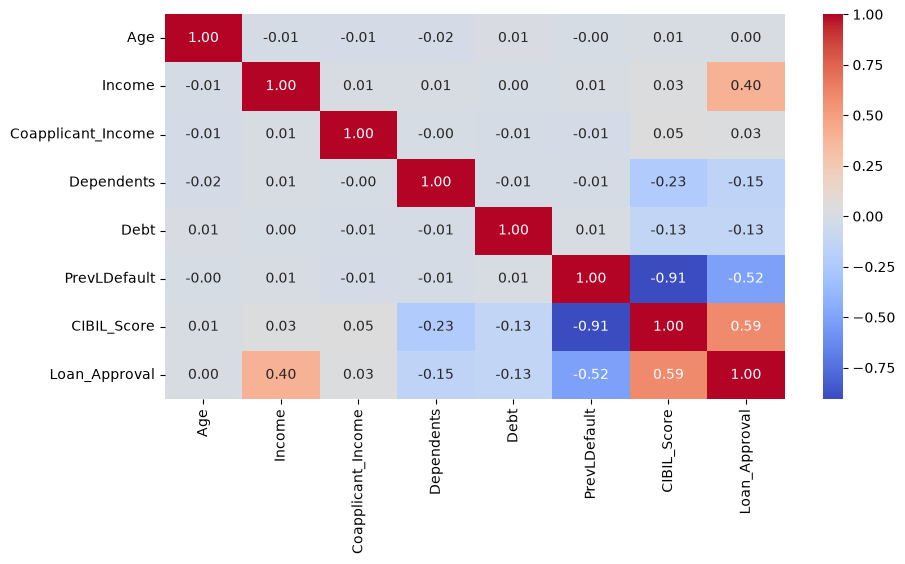

In [65]:
plt.figure(figsize=(10,5))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['Loan_Approval']), df['Loan_Approval'],
    test_size=0.2, random_state=42
)

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_train = scaler.fit_transform(X_train[['CIBIL_Score', 'PrevLDefault']])
scaled_test  = scaler.transform(X_test[['CIBIL_Score', 'PrevLDefault']])

pca = PCA(n_components=1)
X_train['Credit_Risk_Combined'] = pca.fit_transform(scaled_train)
X_test['Credit_Risk_Combined']  = pca.transform(scaled_test)

In [79]:
X_train = X_train.drop(columns=['CIBIL_Score', 'PrevLDefault'])
X_test  = X_test.drop(columns=['CIBIL_Score', 'PrevLDefault'])

In [80]:
trf1 = ColumnTransformer([
    ('employ_status',
     OrdinalEncoder(categories=[['Unemployed', 'Employed', 'Self-employed']],
                     handle_unknown='use_encoded_value',
                     unknown_value=-1),
     ['Employ_Status'])
], remainder='passthrough')

result  = trf1.fit_transform(X_train)
result1 = trf1.transform(X_test)   # transform, not fit_transform, on test

Employment_train = pd.DataFrame(result, columns=trf1.get_feature_names_out())
Employment_test  = pd.DataFrame(result1, columns=trf1.get_feature_names_out())

Employment_train.columns = [c.replace("remainder__", "").replace("employ_status__", "") for c in Employment_train.columns]
Employment_test.columns  = [c.replace("remainder__", "").replace("employ_status__", "") for c in Employment_test.columns]


In [81]:
Employment_train

,Employ_Status,Age,Income,Coapplicant_Income,Dependents,Debt,Credit_Risk_Combined
0,2.0,46.0,59919.0,66406.0,4.0,6322.0,-1.447703
1,2.0,38.0,148339.0,1214.0,1.0,44037.0,1.155246
2,1.0,65.0,86447.0,10673.0,2.0,2395.0,1.587508
3,0.0,68.0,99438.0,85982.0,4.0,67552.0,-1.526296
4,0.0,50.0,65202.0,79154.0,4.0,27458.0,-1.654010
...,...,...,...,...,...,...,...
3995,0.0,65.0,86874.0,74766.0,3.0,1521.0,-1.457527
3996,0.0,37.0,103570.0,42480.0,0.0,75027.0,-1.261045
3997,1.0,26.0,56099.0,55221.0,1.0,33205.0,-1.064562
3998,0.0,35.0,146002.0,16101.0,3.0,73533.0,1.263311


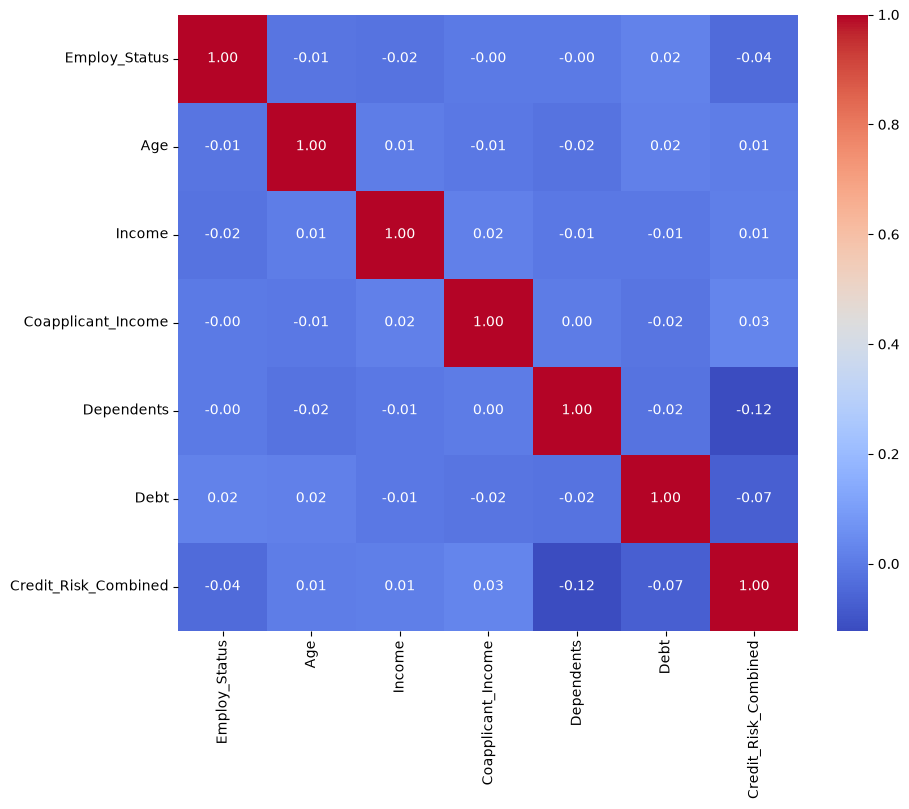

In [82]:
plt.figure(figsize=(10,8))
corr_matrix = Employment_train.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [83]:
xgb_classifier = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_classifier.fit(Employment_train, y_train)
y_pred = xgb_classifier.predict(Employment_test)
print('Train accuracy:', accuracy_score(y_train, xgb_classifier.predict(Employment_train)))
print('Test accuracy :', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Train accuracy: 0.98575
Test accuracy : 0.978

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       507
           1       0.99      0.97      0.98       493

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [84]:
print("Accuracy",accuracy_score(y_test,y_pred)*100)

Accuracy 97.8


In [85]:
from sklearn.model_selection import cross_val_score
model = XGBClassifier()
print("Training",np.mean(cross_val_score(model,Employment_train,y_train,scoring='accuracy',cv=10))*100)
print("Testing",np.mean(cross_val_score(model,Employment_test,y_test,scoring='accuracy',cv=10))*100)

Training 97.95000000000002
Testing 97.19999999999999


In [86]:
importances = pd.Series(
    xgb_classifier.feature_importances_,
    index=Employment_train.columns
).sort_values(ascending=False)

print(importances)

Employ_Status           0.514737
Credit_Risk_Combined    0.263928
Income                  0.151924
Dependents              0.027542
Debt                    0.023165
Coapplicant_Income      0.010785
Age                     0.007918
dtype: float32
